--- 1. Problem Definition ---
Business Problem: Early detection of liver cirrhosis to enable timely medical intervention.
Business Requirements: Develop a highly accurate ML model that can predict the likelihood of a patient having liver cirrhosis based on standard clinical and demographic data.
Social/Business Impact: Reduces mortality rates, lowers healthcare costs through early treatment, and improves patient quality of life. Optimizes allocation of hepatology resources.


--- 2. Data Collection & Preparation ---
Dataset loaded successfully. Shape: (583, 11)
First 5 rows:
   Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
0   65  Female              0.7               0.1                   187   
1   62    Male             10.9               5.5                   699   
2   62    Male              7.3               4.1                   490   
3   58    Male              1.0               0.4                   182   
4   72    Male              3.9            

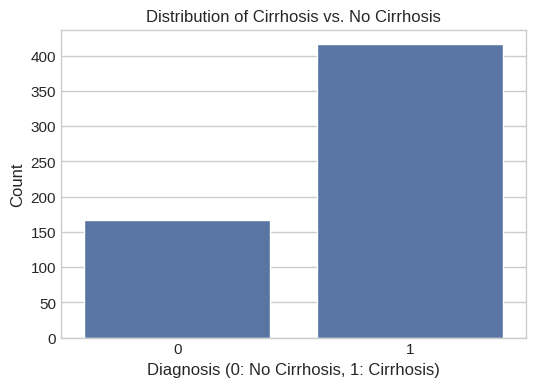

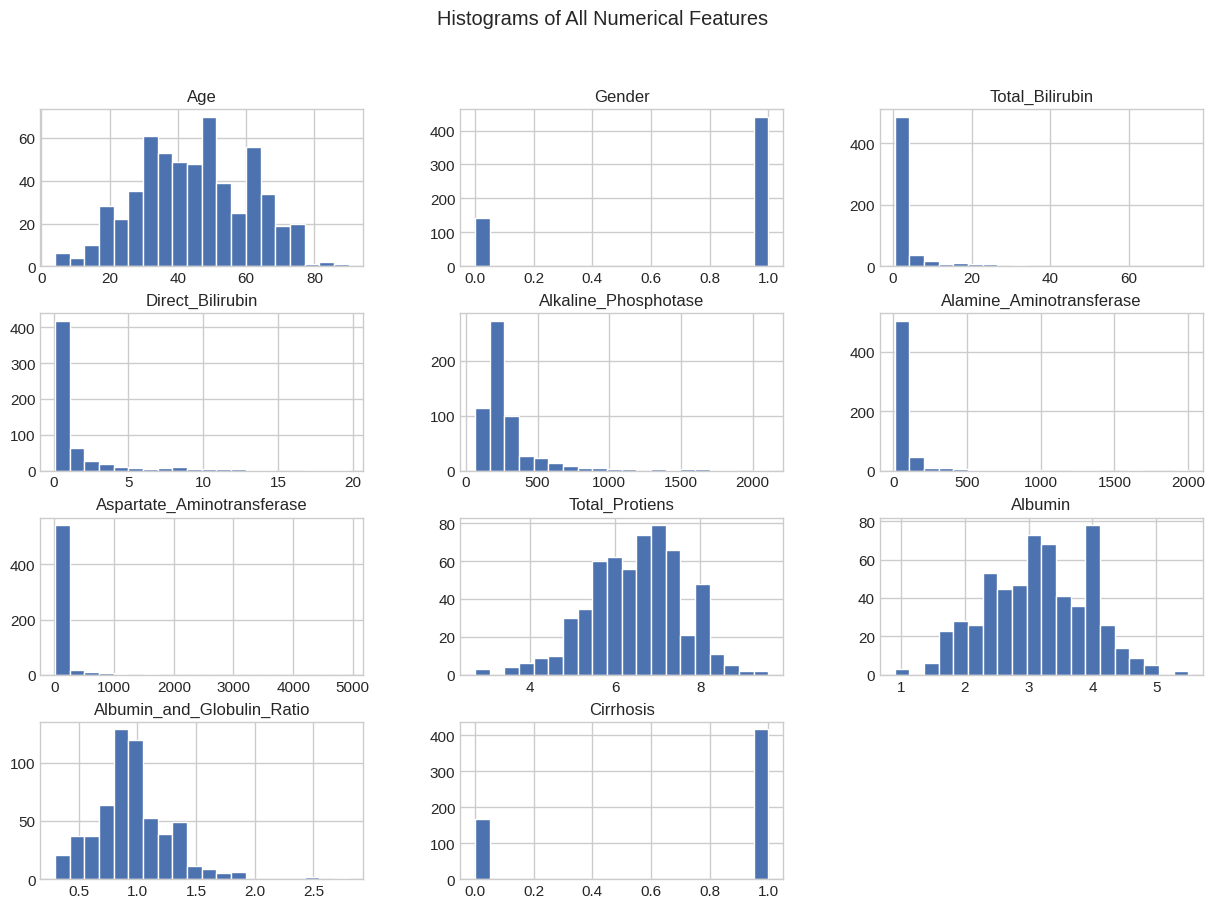

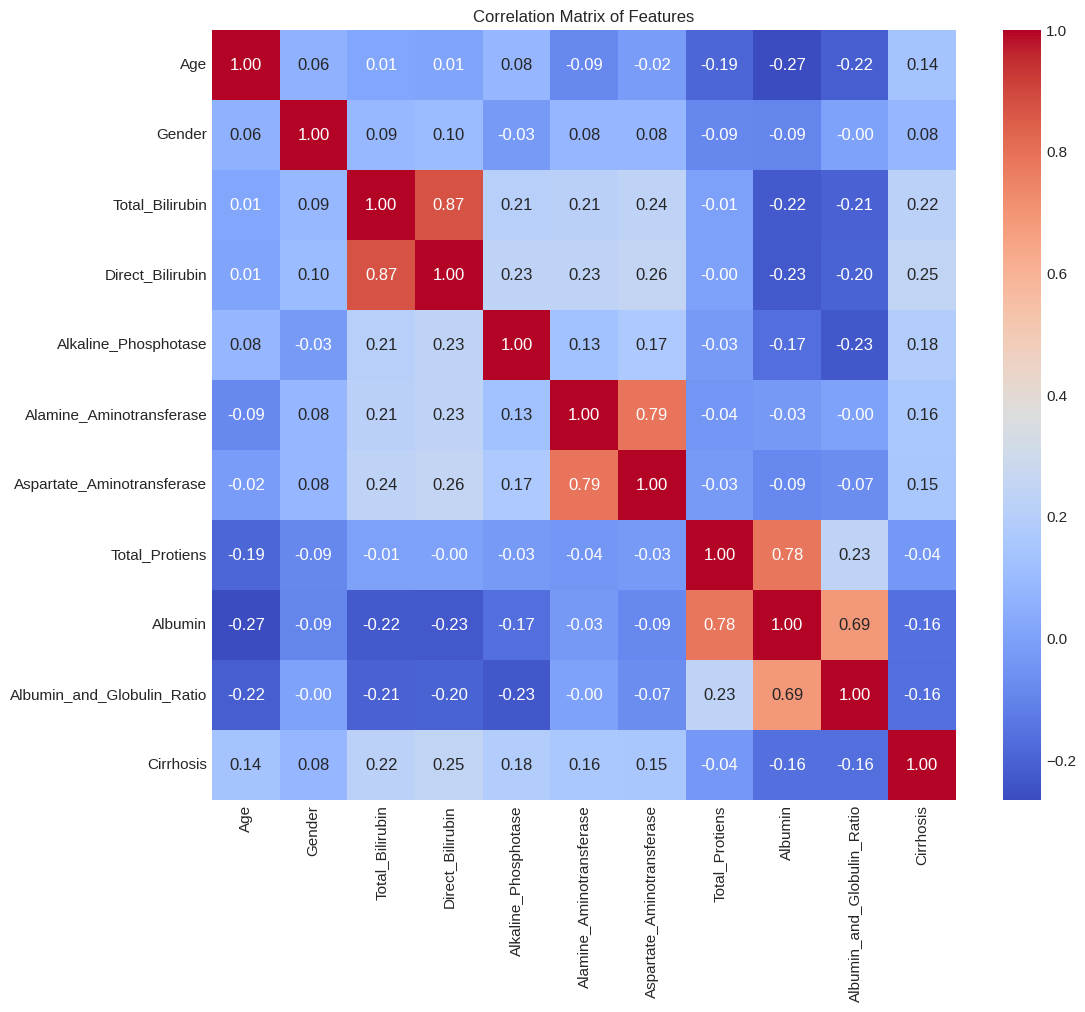


--- 4. Model Building ---
Training set size: 466 samples
Test set size: 117 samples

--- Logistic Regression ---
Accuracy: 0.7350
              precision    recall  f1-score   support

           0       0.67      0.18      0.28        34
           1       0.74      0.96      0.84        83

    accuracy                           0.74       117
   macro avg       0.70      0.57      0.56       117
weighted avg       0.72      0.74      0.68       117


--- K-Nearest Neighbors ---
Accuracy: 0.6838
              precision    recall  f1-score   support

           0       0.43      0.26      0.33        34
           1       0.74      0.86      0.79        83

    accuracy                           0.68       117
   macro avg       0.58      0.56      0.56       117
weighted avg       0.65      0.68      0.66       117


--- Decision Tree ---
Accuracy: 0.5983
              precision    recall  f1-score   support

           0       0.29      0.26      0.28        34
           1       0

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:16:37] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [09:17:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Best Parameters found: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200}

--- XGBoost Performance Comparison ---
Accuracy Before Tuning: 0.7350
Accuracy After Tuning: 0.7009

Classification Report for Tuned XGBoost Model:
              precision    recall  f1-score   support

           0       0.44      0.12      0.19        34
           1       0.72      0.94      0.82        83

    accuracy                           0.70       117
   macro avg       0.58      0.53      0.50       117
weighted avg       0.64      0.70      0.63       117


Confusion Matrix for Tuned XGBoost Model:


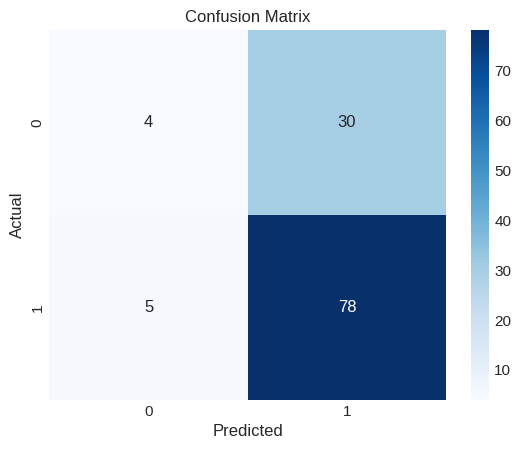


--- 6. Saving the Best Model ---
Tuned XGBoost model saved as model.pkl


In [1]:
# In[1]:
# Step 1: Import Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import pickle

# Set plot style
sns.set(style="whitegrid")
plt.style.use("seaborn-v0_8-whitegrid")


# In[2]:
# ###############################################
# Section 1: Define Problem / Problem Understanding
# ###############################################
print("--- 1. Problem Definition ---")
print("Business Problem: Early detection of liver cirrhosis to enable timely medical intervention.")
print("Business Requirements: Develop a highly accurate ML model that can predict the likelihood of a patient having liver cirrhosis based on standard clinical and demographic data.")
print("Social/Business Impact: Reduces mortality rates, lowers healthcare costs through early treatment, and improves patient quality of life. Optimizes allocation of hepatology resources.")
print("\n")


# In[3]:
# ###############################################
# Section 2: Data Collection & Preparation
# ###############################################
print("--- 2. Data Collection & Preparation ---")

# Load the dataset from a reliable source (e.g., Kaggle or UCI repo direct link)
# Column names are based on the dataset's description
column_names = ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase',
                'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens',
                'Albumin', 'Albumin_and_Globulin_Ratio', 'Dataset']

# URL for the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00225/Indian%20Liver%20Patient%20Dataset%20(ILPD).csv"
df = pd.read_csv(url, header=None, names=column_names)

print("Dataset loaded successfully. Shape:", df.shape)
print("First 5 rows:")
print(df.head())


# In[4]:
# --- Data Preparation ---

# Check for missing values
print("\nMissing values before handling:")
print(df.isnull().sum())

# The 'Albumin_and_Globulin_Ratio' has 4 missing values. We will fill them with the median.
df['Albumin_and_Globulin_Ratio'] = df['Albumin_and_Globulin_Ratio'].fillna(df['Albumin_and_Globulin_Ratio'].median())

print("\nMissing values after handling:")
print(df.isnull().sum())


# In[5]:
# --- Feature Engineering & Encoding ---

# Encode the 'Gender' column: Male -> 1, Female -> 0
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# The 'Dataset' column is our target variable. 1 indicates cirrhosis, 2 indicates no cirrhosis.
# Let's map it to a more intuitive 1 (cirrhosis) and 0 (no cirrhosis).
df['Dataset'] = df['Dataset'].apply(lambda x: 1 if x == 1 else 0)
# Renaming for clarity
df.rename(columns={'Dataset': 'Cirrhosis'}, inplace=True)

print("\nData after encoding and mapping target variable:")
print(df.head())


# In[6]:
# ###############################################
# Section 3: Exploratory Data Analysis (EDA)
# ###############################################
print("\n--- 3. Exploratory Data Analysis ---")

# Descriptive Statistics
print("\nDescriptive Statistics:")
print(df.describe())


# In[7]:
# Visual Analysis

# Distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='Cirrhosis', data=df)
plt.title('Distribution of Cirrhosis vs. No Cirrhosis')
plt.xlabel('Diagnosis (0: No Cirrhosis, 1: Cirrhosis)')
plt.ylabel('Count')
plt.show()


# In[8]:
# Histograms for all numerical features
df.hist(bins=20, figsize=(15, 10))
plt.suptitle('Histograms of All Numerical Features')
plt.show()


# In[9]:
# Correlation Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()


# In[10]:
# ###############################################
# Section 4: Model Building
# ###############################################
print("\n--- 4. Model Building ---")

# Define features (X) and target (y)
X = df.drop('Cirrhosis', axis=1)
y = df['Cirrhosis']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling - Important for KNN and Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


# In[11]:
# --- Training multiple algorithms ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Store results
results = {}

for name, model in models.items():
    if name in ["Logistic Regression", "K-Nearest Neighbors"]:
        # These models benefit from scaled data
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        # Tree-based models don't require feature scaling
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))


# In[12]:
# #########################################################
# Section 5: Performance Testing & Hyperparameter Tuning
# #########################################################
print("\n--- 5. Performance Testing & Hyperparameter Tuning ---")
print("\nModel Accuracy Comparison (Before Tuning):")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

# Random Forest and XGBoost are usually top performers. Let's tune XGBoost.
print("\n--- Hyperparameter Tuning for XGBoost ---")

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# Initialize GridSearchCV
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='accuracy')

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best estimator
best_xgb = grid_search.best_estimator_
print(f"\nBest Parameters found: {grid_search.best_params_}")

# Evaluate the tuned model
y_pred_tuned = best_xgb.predict(X_test)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print("\n--- XGBoost Performance Comparison ---")
print(f"Accuracy Before Tuning: {results['XGBoost']:.4f}")
print(f"Accuracy After Tuning: {tuned_accuracy:.4f}")

print("\nClassification Report for Tuned XGBoost Model:")
print(classification_report(y_test, y_pred_tuned))

print("\nConfusion Matrix for Tuned XGBoost Model:")
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# In[13]:
# ###############################################
# Section 6: Model Deployment (Saving the Model)
# ###############################################
print("\n--- 6. Saving the Best Model ---")

# We will save the best model (tuned XGBoost) for our web application.
# Note: We also need to save the scaler, but since our best model (XGBoost)
# doesn't require scaling, we can just save the model itself.
# If KNN or Logistic Regression were best, we would save both the model and the scaler.

with open('model.pkl', 'wb') as file:
    pickle.dump(best_xgb, file)

print("Tuned XGBoost model saved as model.pkl")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')